In [ ]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
import myrfecv as mr
import myfunction as mf
path_data_raw = "C:/Users/dell/OneDrive/file/"
path_country_nc = "C:/Users/dell/OneDrive/file/nc"
path_onedrive_csv = "C:/Users/dell/OneDrive/file/csv/"
path_one_spdb = 'C:/Users/dell/OneDrive/file/SPDB/'
drive_letter = 'E:'

path_pre = drive_letter + "/wyy/code_project/running_outcome/final_data/SPDB/part0_treat/pretreatment/"
path_match = drive_letter + "/wyy/code_project/running_outcome/final_data/SPDB/part0_treat/match/"

path_2_preanalysis_data = drive_letter + "/wyy/code_project/running_outcome/final_data/SPDB/part2_analysis/preanalysis/"

path_temp = drive_letter + "/wyy/code_project/running_outcome/final_data/SPDB/part3_forecast/temp/"


meta_name = "meta_data.csv"
list_pfas = ['PFBS', 'PFDA', 'PFHpA', 'PFHxA', 'PFHxS', 'PFNA', 'PFOA', 
             'PFOS', 'FOSA', 'PFDoDA', 'PFTeDA', 'PFUnDA', 'PFTrDA', 
             'HFPO-DA', 'PFBA', 'PFDS', 'PFHpS', 'PFNS', 'PFPeA', 'PFPeS']

In [ ]:

scoring = 'r2'
str_describe = 'lr'
df_lr_data_raw = pd.read_csv(path_match + "lr_match_treat_full.csv")

df_lr_data_raw['year'] = (df_lr_data_raw['year'] - 2000) / (2020 - 2000)
columns_to_drop = ['lon_grid', 'lat_grid', 'posname', 'log_Koa_wet', 'log_Koc', 'log_KHxd_air', 'log_Kaw']
df_lr_data = df_lr_data_raw.drop(columns=columns_to_drop)

print(df_lr_data.columns)

path_lr_rfecv_data = drive_letter + '/wyy/code_project/running_outcome/final_data/SPDB/part3_forecast/lr_forecast/'
path_lr_rfecv_fig = drive_letter + '/wyy/code_project/running_outcome/final_fig/SPDB/part3_forecast/lr_forecast/'


Index(['sshf', 'SWD_INC_CO2_E', 'lict', 'density', 'HCFC', 'sp',
       'paper_consumption', 'ltlt', 'global_salinity', 'TOTALS_CO2_E', 'dl',
       'licd', 'z', 'solubility', 'tcsw', 'skt', 'C2F6', 'cfc', 'logPx', 'tp',
       'ssro', 'night_lights', 'po_m_w', 'SF6', 'organ_muscle', 'po_chain',
       'log_Koil_w', 'log_pKa', 'i10fg', 'population', 'GDP',
       'wrap_consumption', 'value', 'sro', 'cl', 'logD5_5', 'po_f_carbon',
       'fluorite_consumption', 'po_carbon', 'ssr', 'stl1', 'sp_weight',
       'TNR_Ship_CO2_E', 'swvl1', 'cth', 'HFC', 'e', 'organ_liver', 'si10',
       'ctp', 'nships_smoothed', 'tcrw', 'sp_length', 'sp_troph', 'logD7_4',
       'str', 'CF4', 'ctt', 'year', 'sw_value'],
      dtype='object')


GBDT Optimal number of features: 32
RF Optimal number of features: 45
LGBM Optimal number of features: 47


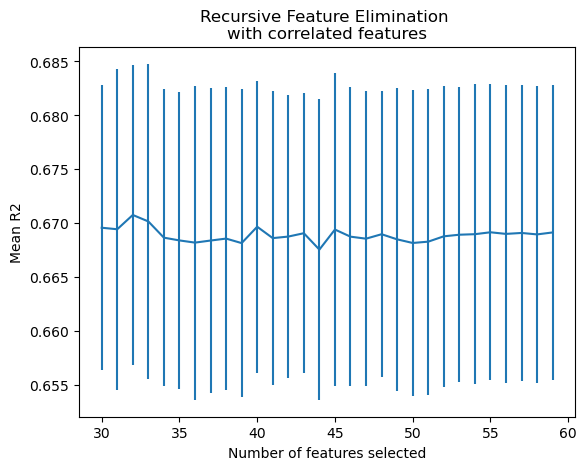

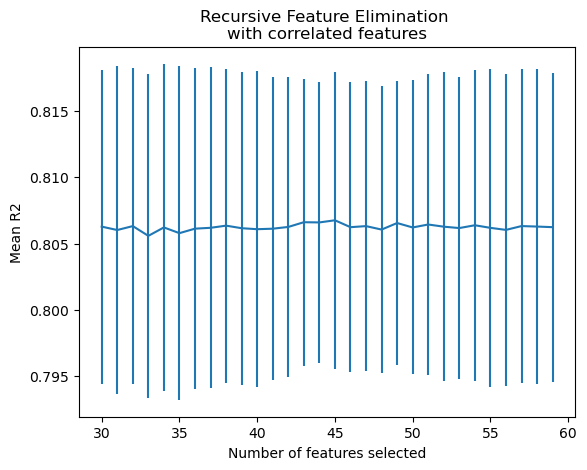

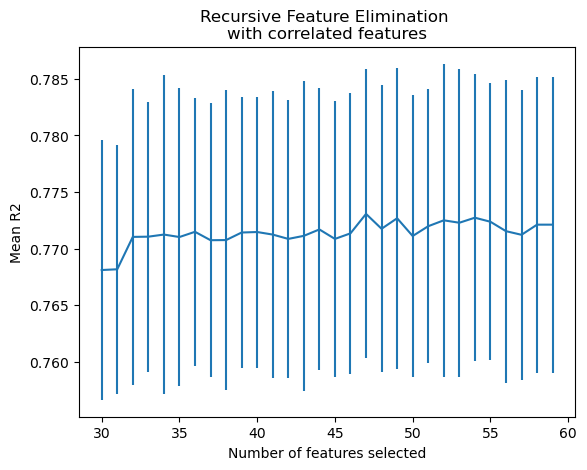

In [ ]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from lightgbm import LGBMRegressor
dict_clf = {
    'GBDT': GradientBoostingRegressor(random_state=202406),
    'RF': RandomForestRegressor(random_state=202406),
    'LGBM': LGBMRegressor(random_state=202406)
}

for key, clf in dict_clf.items():
    mr.start_rfecv(key, clf, df_lr_data, str_describe, path_lr_rfecv_data, path_lr_rfecv_fig, 'cv')


In [ ]:
df_lgbm = pd.read_csv(path_lr_rfecv_data + 'lr_rfecv_features_LGBMcv.csv')

df_lgbm['Importance'] = df_lgbm['Importance'] / df_lgbm['Importance'].sum()

df_lgbm.to_csv(path_lr_rfecv_data + 'lr_rfecv_features_LGBMcv.csv', index=False)

In [ ]:

model_configs = {
        'RF': {
            'model_class': RandomForestRegressor,
            'param_grid': {
                'n_estimators': [200, 300],
                'max_depth': [None,10],
                'min_samples_split': [2, 4, 6],
                'min_samples_leaf': [1, 2, 3],
            }
        },
        'GBDT': {
            'model_class': GradientBoostingRegressor,
            'param_grid': {
                'n_estimators': [200, 300],
                'learning_rate': [0.1],
                'max_depth': [None,10],
                'min_samples_split': [2, 4, 6],
                'min_samples_leaf': [1, 2, 3],
            }
        },
        'LGBM': {
            'model_class': LGBMRegressor,
            'fixed_params': {'verbose': -1}, 
            'param_grid': {
                'n_estimators': [200, 300],
                'learning_rate': [0.1],
                'max_depth': [None, 10],
                'num_leaves': [31, 63, 127],
                'min_child_samples': [1, 2, 3]
            }
        }
    }

cv_result = mr.grid_search_param(
    df_lr_data, 
    str_describe, 
    scoring, 
    path_lr_rfecv_data, 
    model_configs, 
    'cv'
)


cv_result.to_csv(path_lr_rfecv_data + 'ml_cv_results.csv', index=False)


lr RF
Best parameters for RF: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 300}
lr GBDT
Best parameters for GBDT: {'learning_rate': 0.1, 'max_depth': 10, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 200}
lr LGBM
Best parameters for LGBM: {'learning_rate': 0.1, 'max_depth': None, 'min_child_samples': 2, 'n_estimators': 300, 'num_leaves': 127}


In [6]:
cv_result = pd.read_csv(path_lr_rfecv_data + 'ml_cv_results.csv')
results = mr.get_tree_best_model(cv_result)
results.to_csv(path_lr_rfecv_data + 'ml_cv_best.csv', index=False)
results = pd.read_csv(path_lr_rfecv_data + 'ml_cv_best.csv')
for index, value in results['param_max_depth'].items():
    if pd.isna(value) or value == '':
        results.at[index, 'param_max_depth'] = 'None'
results.to_csv(path_lr_rfecv_data + 'ml_cv_best.csv', index=False)

In [ ]:
df_lr_rf_rfecv = pd.read_csv(path_lr_rfecv_data + 'lr_rfecv_r2_RFcv.csv')
df_lr_rf_rfecv['model'] = 'RF'
df_lr_gbdt_rfecv = pd.read_csv(path_lr_rfecv_data + 'lr_rfecv_r2_GBDTcv.csv')
df_lr_gbdt_rfecv['model'] = 'GBDT'
df_lr_lgbm_rfecv = pd.read_csv(path_lr_rfecv_data + 'lr_rfecv_r2_LGBMcv.csv')
df_lr_lgbm_rfecv['model'] = 'LGBM'


df_lr_rfecv = pd.concat([df_lr_rf_rfecv, df_lr_gbdt_rfecv, df_lr_lgbm_rfecv],axis=0)

df_lr_rfecv = df_lr_rfecv.sort_values(by='mean_test_score', ascending=False)
print(df_lr_rfecv.head())
max_index = df_lr_rfecv['mean_test_score'].idxmax()
min_features = df_lr_rfecv.loc[max_index, 'min_features'].tolist()[0]
max_model = df_lr_rfecv.loc[max_index, 'model'].tolist()[0]
max_score = round(df_lr_rfecv.loc[max_index, 'mean_test_score'].tolist()[0],3)
df_lr_rfecv.to_csv(path_lr_rfecv_data + 'lr_merge_rfecv.csv',index=False)
print(f'model:{max_model} min_feature:{min_features} score:{max_score}')

In [ ]:

selected_features_gbdt = pd.read_csv(path_lr_rfecv_data + str_describe + "_rfecv_features_GBDTcv.csv")
selected_features_gbdt = selected_features_gbdt[selected_features_gbdt["Rank"] == 1]["Feature"].values

selected_features_rf = pd.read_csv(path_lr_rfecv_data + str_describe + "_rfecv_features_RFcv.csv")
selected_features_rf = selected_features_rf[selected_features_rf["Rank"] == 1]["Feature"].values

best_params = pd.read_csv(path_lr_rfecv_data + 'ml_cv_best.csv')

results  = mr.tree_inf(df_lr_data, selected_features_gbdt, selected_features_rf, best_params)
print("GBDT R2 scores for each fold:", results['gbdt_r2'])
print("GBDT MSE scores for each fold:", results['gbdt_mse'])
print("RF R2 scores for each fold:", results['rf_r2'])
print("RF MSE scores for each fold:", results['rf_mse'])

Average R2 for GBDT: 0.8161489409660774
Average MSE for GBDT: 0.17960421760206127
Average R2 for RF: 0.8348798686273164
Average MSE for RF: 0.1613446015666941
GBDT R2 scores for each fold: [0.8226889085405348, 0.8170747858188783, 0.8249953719933303, 0.8238819006429547, 0.7989181551380783, 0.8248382322432639, 0.8157149568469122, 0.832167529359549, 0.7921033017413739, 0.809106267335899]
GBDT MSE scores for each fold: [0.17781352430042371, 0.16999215729206765, 0.17553774983222536, 0.17229112200319568, 0.19267876812693302, 0.18926809525974464, 0.18489736174580088, 0.16901254247292485, 0.18159697180355794, 0.18295388318373898]
RF R2 scores for each fold: [0.8492716289631526, 0.8358171180801391, 0.8429863618488842, 0.8288071323585495, 0.8235073686206046, 0.8349835748627029, 0.8430359742692846, 0.8444606378519266, 0.8099784014319924, 0.8359504879859274]
RF MSE scores for each fold: [0.15115547846171154, 0.15257493294692182, 0.157491953486897, 0.16747291364469408, 0.16911712154329095, 0.178305

## 未知PFAS

In [ ]:

import random
scoring = 'r2'
str_describe = 'sw'

path_sw_rfecv_data = drive_letter + '/wyy/code_project/running_outcome/final_data/SPDB/part3_forecast/sw_forecast/'

df_sw_sem_all = pd.read_csv(path_match + 'sw_match_treat.csv')
df_sw_sem_all['year'] = (df_sw_sem_all['year'] - 2000) / (2020 - 2000)

df_sw_select_train = df_sw_sem_all[df_sw_sem_all['posname'].isin(list_pfas)]
df_sw_select_test = df_sw_sem_all[~df_sw_sem_all['posname'].isin(list_pfas)]
print(df_sw_select_train.shape, df_sw_select_test.shape)


(14266, 60) (862, 60)


In [ ]:


random_seeds = random.sample(range(20250307), 10)
print("随机生成的种子：", random_seeds)
results_df, stats_df = mf.run_stacking_validation(df_sw_sem_all, df_sw_select_train, df_sw_select_test, path_sw_rfecv_data, str_describe, random_seeds)
print(stats_df)

In [ ]:

r2, mse, rmse = mr.additional_validation(df_sw_select_train, df_sw_select_test, path_sw_rfecv_data, str_describe, 'cv')
print(r2, mse, rmse)

LGBM
0.7646314245669756 0.25431381001307257 0.5042953598964327
